# Install and Import Package


In [1]:
%pip install requests
%pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
# Fix SSL certificate issue temporarily 
import ssl
import nltk
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
import time


# Step 1: Crawl a Real-World Dataset

In [3]:
import requests
import json
import numpy as np
import pandas as pd

In [4]:
subreddit = 'apple'
timeframe = 'year'   # hour, day, week, month, year, all
listing = 'top' # controversial, best, hot, new, random, rising, top
limit = 250    

In [5]:
def get_reddit(subreddit, listing, limit, timeframe):
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit:', e)
        return None
    return request

def get_reddit_after(subreddit, listing, limit, timeframe, after_token):
    """Get Reddit posts after a specific token (pagination)."""
    try:
        base_url = (
            f'https://www.reddit.com/r/{subreddit}/{listing}.json'
            f'?limit={limit}&t={timeframe}&after={after_token}'
        )
        request = requests.get(base_url, headers={'User-agent': 'SDPA'})
    except Exception as e:
        print('An Error Occurred in get_reddit_after:', e)
        return None
    return request

In [6]:
r = get_reddit(subreddit, listing, limit, timeframe)
data = json.loads(r.content)

temp = []
children = data['data']['children']
print("Page 1 posts:", len(children))

for i in range(len(children)):
    post = children[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top100 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  2nd 100 posts 
after_token = data['data']['children'][len(children)-1]['kind'] + '_' + \
              data['data']['children'][len(children)-1]['data']['id']

r_new = get_reddit_after(subreddit, listing, limit, timeframe, after_token)
data_second = json.loads(r_new.content)

temp = []
children2 = data_second['data']['children']
print("Page 2 posts:", len(children2))

for i in range(min(100, len(children2))):
    post = children2[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top200 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

#  3rd 
after_token_second = children2[len(children2)-1]['kind'] + '_' + \
                     children2[len(children2)-1]['data']['id']

r_new2 = get_reddit_after(subreddit, listing, limit, timeframe, after_token_second)
data_third = json.loads(r_new2.content)

temp = []
children3 = data_third['data']['children']
print("Page 3 posts:", len(children3))

for i in range(len(children3)):
    post = children3[i]['data']
    temp.append([
        post['title'],
        post['ups'],
        post['link_flair_text'],
        post['num_comments'],
        post['selftext'],
        post['created_utc'],
        post['id']
    ])

top250 = pd.DataFrame(
    np.array(temp, dtype=object),
    columns=['Title', 'Upvotes', 'Flair', 'Num_Comments',
             'Body', 'Created_UTC', 'Post_ID']
)

# Combine all into one dataset 
top_reddit_posts = pd.concat([top100, top200, top250], ignore_index=True)
top_reddit_posts['Upvotes'] = pd.to_numeric(top_reddit_posts['Upvotes'])
top_reddit_posts['Num_Comments'] = pd.to_numeric(top_reddit_posts['Num_Comments'])

print("Final combined shape:", top_reddit_posts.shape)
top_reddit_posts.to_csv('reddit_top_posts_year.csv', index=False)
top_reddit_posts

Page 1 posts: 100
Page 2 posts: 100
Page 3 posts: 51
Final combined shape: (251, 7)


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13578,iPhone,1363,,1743785410.0,1jrgmvl
1,Most iPhone owners see little to no value in A...,11261,Apple Intelligence,1432,,1734363217.0,1hflpje
2,Apple shareholders say no to scrapping company...,9865,Discussion,701,,1740503162.0,1ixzyrj
3,Apple sued for false advertising over Apple In...,8765,Apple Intelligence,611,,1742509626.0,1jg1k6j
4,Apple is racing to fly planes of iPhones into ...,7789,iPhone,550,,1744054856.0,1jtu9k4
...,...,...,...,...,...,...,...
246,Apple wants the iPhone 17 Pro to replace your ...,1472,iPhone,482,,1740369229.0,1iwt1cj
247,An update on Blood Oxygen for Apple Watch in t...,1469,Apple Newsroom,282,,1755179314.0,1mq172h
248,Apple announces chief operating officer transi...,1471,Apple Newsroom,162,,1752007424.0,1luzs4q
249,iPhone 17 Air Launching Later This Year With T...,1469,iPhone,461,,1745508497.0,1k6v2ir


# Step 2: Perform data preparation and cleaning 

## Add features column

In [7]:
top_reddit_posts['Created_At'] = pd.to_datetime(top_reddit_posts['Created_UTC'], unit='s')
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13578,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10
1,Most iPhone owners see little to no value in A...,11261,Apple Intelligence,1432,,1734363217.0,1hflpje,2024-12-16 15:33:37
2,Apple shareholders say no to scrapping company...,9865,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02
3,Apple sued for false advertising over Apple In...,8765,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06
4,Apple is racing to fly planes of iPhones into ...,7789,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56
...,...,...,...,...,...,...,...,...
246,Apple wants the iPhone 17 Pro to replace your ...,1472,iPhone,482,,1740369229.0,1iwt1cj,2025-02-24 03:53:49
247,An update on Blood Oxygen for Apple Watch in t...,1469,Apple Newsroom,282,,1755179314.0,1mq172h,2025-08-14 13:48:34
248,Apple announces chief operating officer transi...,1471,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44
249,iPhone 17 Air Launching Later This Year With T...,1469,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17


In [ ]:
 # Remove ALL old VADER columns if they exist (In case rerun the code)
cols_to_remove = [
    'Title_compound', 'Title_Sent',
    'title_neg', 'title_neu', 'title_pos', 
    'title_compound'
]

top_reddit_posts.drop(
    columns=[c for c in cols_to_remove if c in top_reddit_posts.columns],
    inplace=True
)

# calculate new sentiment 
results = []

for headline in top_reddit_posts['Title']:
    sentiment = sia.polarity_scores(headline)
    compound = sentiment['compound']

    if compound >= 0.05:
        sentiment_class = 'Positive'
    elif compound <= -0.05:
        sentiment_class = 'Negative'
    else:
        sentiment_class = 'Neutral'
    
    results.append({
        'Title_compound': compound,
        'Title_Sent': sentiment_class
    })


sentimental_title = pd.DataFrame(results)

# Combine table 
top_reddit_posts = pd.concat([top_reddit_posts, sentimental_title], axis=1)
top_reddit_posts['Title_compound'] = pd.to_numeric(top_reddit_posts['Title_compound'])


sentimental_title

,Title_compound,Title_Sent
0,0.0000,Neutral
1,0.5130,Positive
2,-0.2960,Negative
3,0.4767,Positive
4,0.0000,Neutral
...,...,...
246,0.0000,Neutral
247,0.0000,Neutral
248,0.0000,Neutral
249,0.0000,Neutral


In [9]:
# Title word count
top_reddit_posts["title_word_count"] = top_reddit_posts["Title"].astype(str).str.split().str.len()

# Body word count
top_reddit_posts["body_word_count"] = top_reddit_posts["Body"].astype(str).str.split().str.len()

In [10]:
top_reddit_posts

,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Title_compound,Title_Sent,title_word_count,body_word_count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13578,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,0.0000,Neutral,14,0
1,Most iPhone owners see little to no value in A...,11261,Apple Intelligence,1432,,1734363217.0,1hflpje,2024-12-16 15:33:37,0.5130,Positive,13,0
2,Apple shareholders say no to scrapping company...,9865,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,-0.2960,Negative,9,0
3,Apple sued for false advertising over Apple In...,8765,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,0.4767,Positive,8,0
4,Apple is racing to fly planes of iPhones into ...,7789,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,0.0000,Neutral,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...
246,Apple wants the iPhone 17 Pro to replace your ...,1472,iPhone,482,,1740369229.0,1iwt1cj,2025-02-24 03:53:49,0.0000,Neutral,13,0
247,An update on Blood Oxygen for Apple Watch in t...,1469,Apple Newsroom,282,,1755179314.0,1mq172h,2025-08-14 13:48:34,0.0000,Neutral,11,0
248,Apple announces chief operating officer transi...,1471,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,0.0000,Neutral,6,0
249,iPhone 17 Air Launching Later This Year With T...,1469,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,0.0000,Neutral,12,0


In [11]:
top_reddit_posts['Flair'] = top_reddit_posts['Flair'].fillna("None")
top_reddit_posts['Body'] = top_reddit_posts['Body'].fillna("")
top_reddit_posts


,Title,Upvotes,Flair,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Title_compound,Title_Sent,title_word_count,body_word_count
0,"iPhones Could Cost Up to $2,300 in the U.S. Du...",13578,iPhone,1363,,1743785410.0,1jrgmvl,2025-04-04 16:50:10,0.0000,Neutral,14,0
1,Most iPhone owners see little to no value in A...,11261,Apple Intelligence,1432,,1734363217.0,1hflpje,2024-12-16 15:33:37,0.5130,Positive,13,0
2,Apple shareholders say no to scrapping company...,9865,Discussion,701,,1740503162.0,1ixzyrj,2025-02-25 17:06:02,-0.2960,Negative,9,0
3,Apple sued for false advertising over Apple In...,8765,Apple Intelligence,611,,1742509626.0,1jg1k6j,2025-03-20 22:27:06,0.4767,Positive,8,0
4,Apple is racing to fly planes of iPhones into ...,7789,iPhone,550,,1744054856.0,1jtu9k4,2025-04-07 19:40:56,0.0000,Neutral,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...
246,Apple wants the iPhone 17 Pro to replace your ...,1472,iPhone,482,,1740369229.0,1iwt1cj,2025-02-24 03:53:49,0.0000,Neutral,13,0
247,An update on Blood Oxygen for Apple Watch in t...,1469,Apple Newsroom,282,,1755179314.0,1mq172h,2025-08-14 13:48:34,0.0000,Neutral,11,0
248,Apple announces chief operating officer transi...,1471,Apple Newsroom,162,,1752007424.0,1luzs4q,2025-07-08 20:43:44,0.0000,Neutral,6,0
249,iPhone 17 Air Launching Later This Year With T...,1469,iPhone,461,,1745508497.0,1k6v2ir,2025-04-24 15:28:17,0.0000,Neutral,12,0


#### HANDLE OUTLIERS

Check for Skewness

In [12]:
cols = ['Upvotes', 'Num_Comments', 'Title_compound', 'title_word_count', 'body_word_count']

for col in cols:
    skew_value = top_reddit_posts[col].skew()
    
    # Interpretation rule
    if abs(skew_value) > 1:
        interpretation = "Highly skewed"
    elif abs(skew_value) > 0.5:
        interpretation = "Moderately skewed"
    else:
        interpretation = "Approximately symmetric"
    
    print(f"{col}: {skew_value:.4f} --> {interpretation}")

Upvotes: 3.3642 --> Highly skewed
Num_Comments: 2.6194 --> Highly skewed
Title_compound: -0.1493 --> Approximately symmetric
title_word_count: 2.5456 --> Highly skewed
body_word_count: 7.6664 --> Highly skewed


**Use Log-Transform on the highly skewed features**

In [13]:
top_reddit_posts['log_Upvotes'] = np.log1p(top_reddit_posts['Upvotes'])
top_reddit_posts['log_Num_Comments'] = np.log1p(top_reddit_posts['Num_Comments'])
top_reddit_posts['log_body_word_count'] = np.log1p(top_reddit_posts['body_word_count'])

## Step 3: Perform exploratory analysis 

In [14]:
numeric_cols = ['log_Upvotes','log_Num_Comments', 'Title_compound', 'title_word_count', 'log_body_word_count']
top_reddit_posts[numeric_cols].describe()

,log_Upvotes,log_Num_Comments,Title_compound,title_word_count,log_body_word_count
count,251.000000,251.000000,251.000000,251.000000,251.000000
mean,7.746277,5.926469,0.028241,12.003984,0.353515
std,0.421041,0.759542,0.304796,5.168751,1.138580
min,7.293018,0.000000,-0.790600,2.000000,0.000000
25%,7.430114,5.527425,0.000000,9.000000,0.000000
50%,7.635304,5.921578,0.000000,11.000000,0.000000
75%,7.924613,6.396880,0.190100,13.000000,0.000000
max,9.516280,7.976939,0.784500,47.000000,6.025866


#### ***Distribution of Flair Post Graph***

In [15]:
top_reddit_posts.groupby('Flair').count()   

,Title,Upvotes,Num_Comments,Body,Created_UTC,Post_ID,Created_At,Title_compound,Title_Sent,title_word_count,body_word_count,log_Upvotes,log_Num_Comments,log_body_word_count
Flair,,,,,,,,,,,,,,
AirPods,13,13,13,13,13,13,13,13,13,13,13,13,13,13
App Store,6,6,6,6,6,6,6,6,6,6,6,6,6,6
Apple Card,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Intelligence,22,22,22,22,22,22,22,22,22,22,22,22,22,22
Apple News+,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Newsroom,5,5,5,5,5,5,5,5,5,5,5,5,5,5
Apple Pay,2,2,2,2,2,2,2,2,2,2,2,2,2,2
Apple Retail,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Apple Silicon,2,2,2,2,2,2,2,2,2,2,2,2,2,2


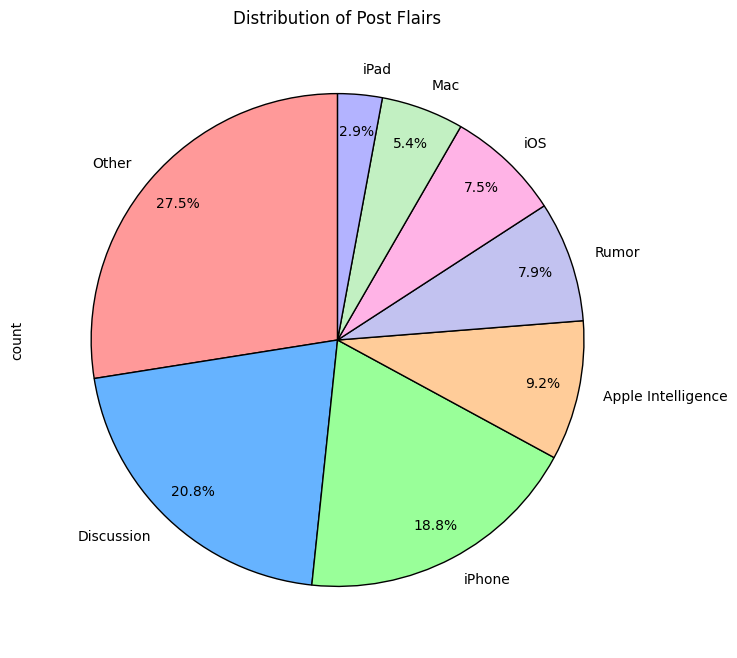

In [ ]:
exclude_flair_none = top_reddit_posts[top_reddit_posts['Flair'] != "None"].copy()

# Normalise text: remove spaces and standardise case (As some of flair have spacebar)
exclude_flair_none['Flair'] = exclude_flair_none['Flair'].str.strip()

main_flairs = [
    'iPhone',
    'Discussion',
    'iOS',
    'Mac',
    'Rumor',
    'iPad',
    'Apple Intelligence'
]

# Clean flairs
flair_clean = exclude_flair_none['Flair'].copy()
flair_clean = flair_clean.where(flair_clean.isin(main_flairs), other='Other')

# Count categories
count_flair = flair_clean.value_counts()

# Custom color palette (8 colors) 
colors = [
    '#ff9999', '#66b3ff', '#99ff99', '#ffcc99',
    '#c2c2f0', '#ffb3e6', '#c2f0c2', '#b3b3ff',
]

# Plot 
plt.figure(figsize=(11,8))
count_flair.plot(
    kind='pie',
    colors=colors[:len(count_flair)],  # Use only the number of categories
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'edgecolor':'black'}
)

plt.title('Distribution of Post Flairs')
plt.show()

In [17]:
count_flair = flair_clean.value_counts()
print(count_flair)

Flair
Other                 66
Discussion            50
iPhone                45
Apple Intelligence    22
Rumor                 19
iOS                   18
Mac                   13
iPad                   7
Name: count, dtype: int64


#### ***Frequent Word Title Relationship***

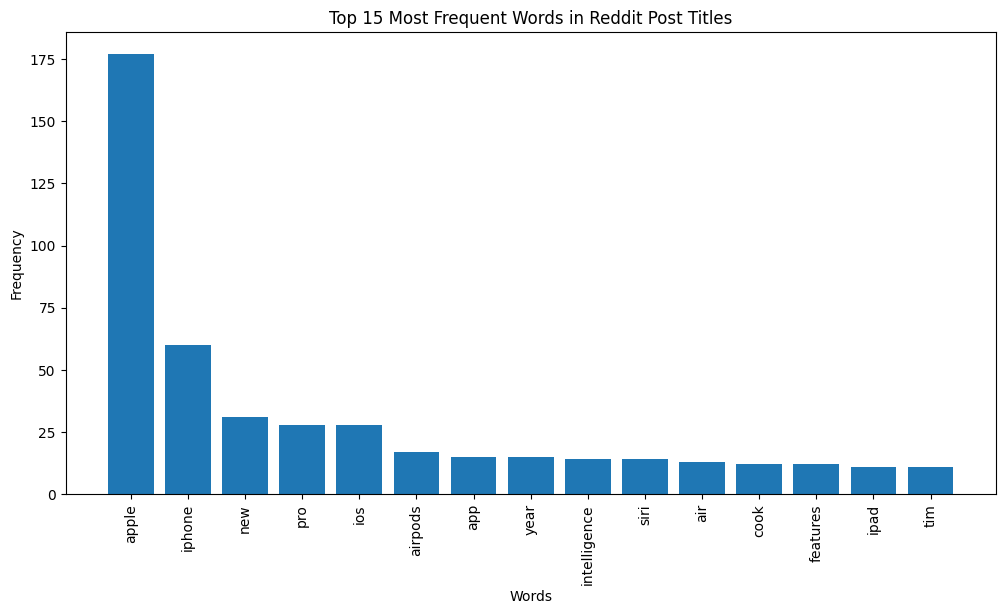

In [ ]:
#  Base English stopwords (Ex. I, You, Is)
stop_words = set(stopwords.words('english'))

#  Add custom unwanted words 
custom_stopwords = {
    'says','reddit'
    }

# Merge them together
stop_words.update(custom_stopwords)

# Clean and extract words from titles 
title_clean = top_reddit_posts['Title'].astype(str).str.lower()

words = []
word_to_titles = {}   # map word -> list of row indexes that contain it

for idx, t in enumerate(title_clean):
    unique_words = set(re.findall(r'\b[a-zA-Z]{3,}\b', t))
    for w in unique_words:
        if w not in stop_words:
            words.append(w)
            word_to_titles.setdefault(w, []).append(idx)

#  Count word frequency 
word_counts = Counter(words)

#  Top 15 most frequent words 
top_words = word_counts.most_common(15)

plt.figure(figsize=(12, 6))
words, counts = zip(*top_words)
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title('Top 15 Most Frequent Words in Reddit Post Titles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

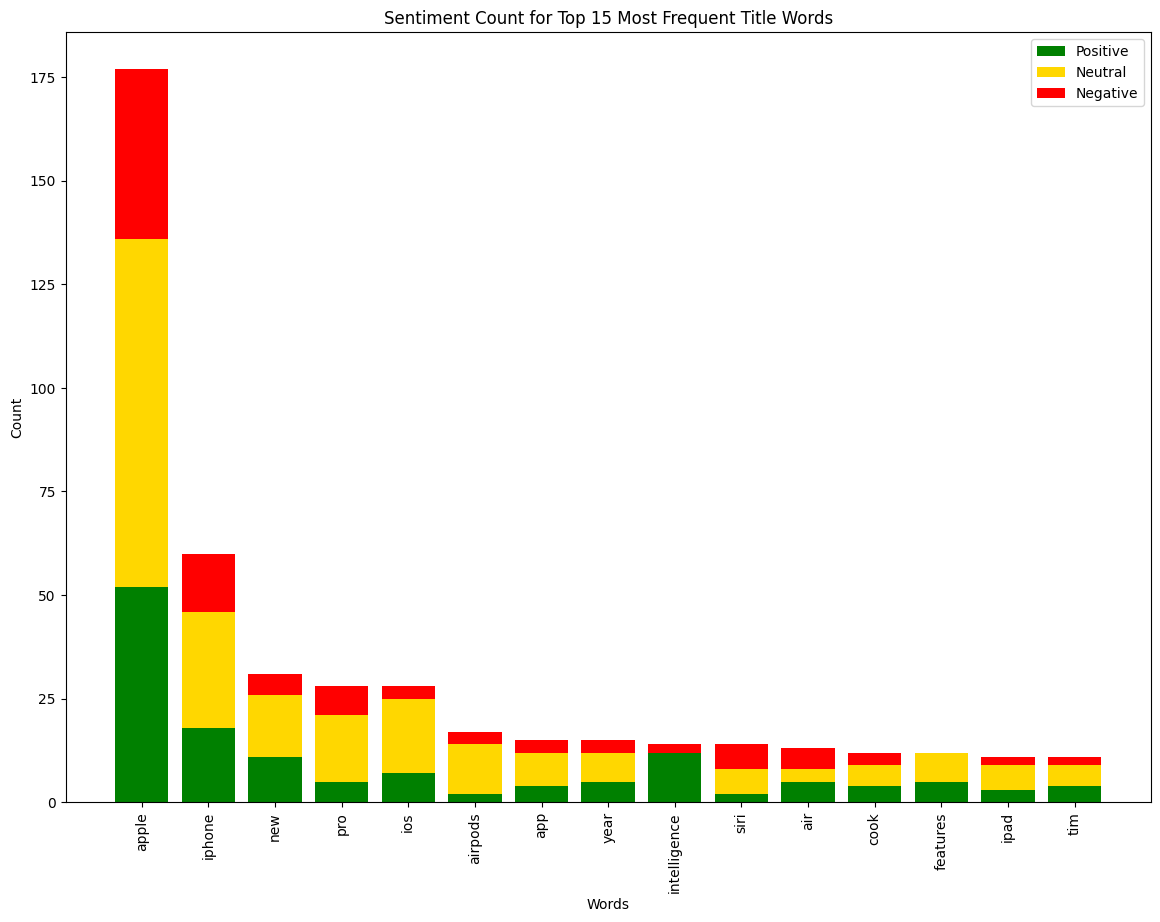

In [ ]:
# Count Sentimental for Each Word 
sentiment_counts = {w[0]: {'Positive': 0, 'Negative': 0, 'Neutral': 0} for w in top_words}

for word_tuple in top_words:
    word = word_tuple[0]
    rows = word_to_titles[word]
    for r in rows:
        sent = top_reddit_posts.loc[r, 'Title_Sent']
        sentiment_counts[word][sent] += 1

#  Lable Stacked Bar Chart
labels = [w[0] for w in top_words]
positive = [sentiment_counts[w]['Positive'] for w in labels]
negative = [sentiment_counts[w]['Negative'] for w in labels]
neutral  = [sentiment_counts[w]['Neutral']  for w in labels]

# Plot stacked bar chart
plt.figure(figsize=(14,10))

plt.bar(labels, positive, label="Positive", color="green")
plt.bar(labels, neutral,  bottom=positive, label="Neutral", color="gold")
plt.bar(labels, negative, bottom=[positive[i] + neutral[i] for i in range(len(labels))], 
        label="Negative", color="red")

plt.xticks(rotation=90)
plt.title("Sentiment Count for Top 15 Most Frequent Title Words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.legend()
plt.show()

In [21]:
top_reddit_posts['Flair_Clean'] = flair_clean
flair_sent = top_reddit_posts[top_reddit_posts['Flair'] != "None"]

# Group by Flair and Title_Sent and count posts
sentiment_flair_counts = (
    flair_sent
    .groupby(['Flair_Clean', 'Title_Sent'])
    .size()                       # count rows
    .unstack(fill_value=0)        # make columns: Positive / Negative / Neutral
    .sort_index()                 # sort by Flair name
)

sentiment_flair_counts

Title_Sent,Negative,Neutral,Positive
Flair_Clean,,,
Apple Intelligence,9,3,10
Discussion,11,30,9
Mac,5,5,3
Other,10,32,24
Rumor,2,13,4
iOS,4,9,5
iPad,1,4,2
iPhone,13,21,11


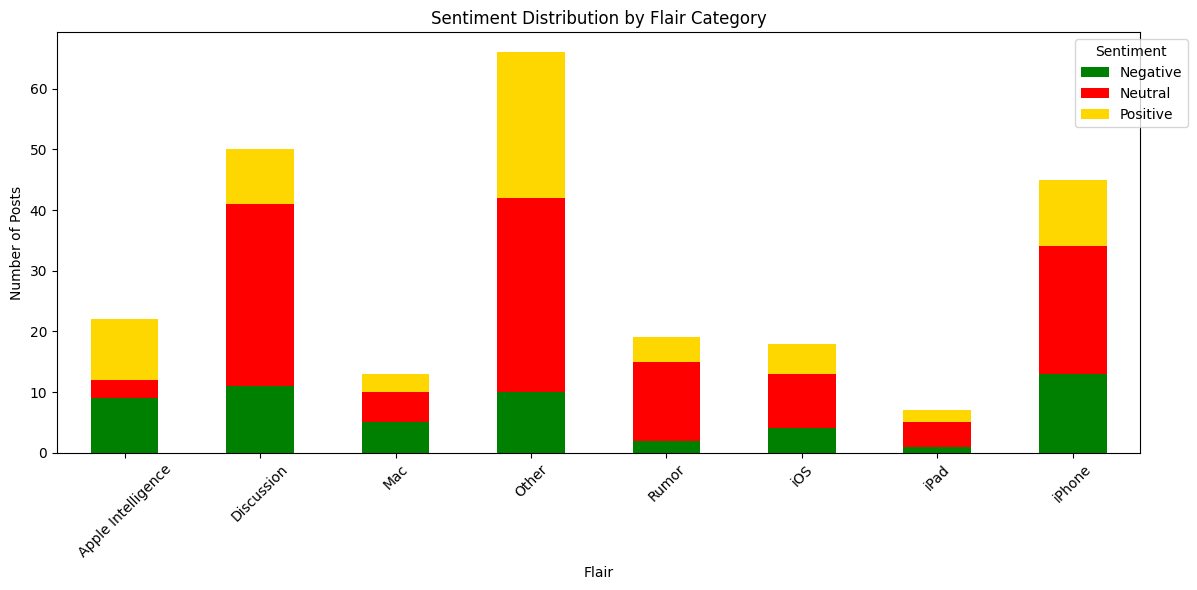

In [22]:
sentiment_by_flair = top_reddit_posts.groupby(
    ['Flair_Clean', 'Title_Sent']
).size().unstack(fill_value=0)

sentiment_by_flair.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['green', 'red', 'gold']
)

plt.title("Sentiment Distribution by Flair Category")
plt.xlabel("Flair")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()